In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import math
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata

In [6]:
from utils.site import Site
from utils.tree import Tree
from utils.constants import ETHZ_COCOA_MAP_THRESHOLDED_FILEPATH, ETHZ_COCOA_MAP_FILEPATH, SILVER_FOLDERPATH, ETHZ_COCOA_MAP_UINT8_FILEPATH

In [4]:
# Check resolution => 1px == 10m x 10m
with rasterio.open(str(ETHZ_COCOA_MAP_FILEPATH)) as src:
    pixel_width, pixel_height = src.res
    
    print(f"Raw pixel width: {pixel_width}")
    print(f"Raw pixel height: {pixel_height}")
    print(f"CRS: {src.crs}") # EPSG:4326 is geographic

    # Figure out pixel actual size (meter)
    bounds = src.bounds
    center_lat = bounds.top # (bounds.bottom + bounds.top) / 2
        
    # Calculate meters per degree of longitude at this specific latitude
    # Formula: 111320.0 * cos(latitude) https://fr.wikipedia.org/wiki/Latitude
    meters_per_degree_lon = 111320.0 * math.cos(math.radians(center_lat))
    
    width_m = pixel_width * meters_per_degree_lon
    height_m = pixel_height * 111320.0
        
    print(f"Based on the map's center latitude ({center_lat:.2f}°)")
    print(f"One pixel: {width_m:.2f} meters wide.")
    print(f"One pixel: {height_m:.2f} meters wide.")

Raw pixel width: 9.055018635493447e-05
Raw pixel height: 9.055023064754131e-05
CRS: EPSG:4326
Based on the map's center latitude (11.17°)
One pixel: 9.89 meters wide.
One pixel: 10.08 meters wide.


In [5]:
UINT8_NODATA = 255 # uint8 NO-DATA value

with rasterio.open(ETHZ_COCOA_MAP_FILEPATH) as src:
    
    # Allocate empty uint8 array 
    binned_data = np.empty(src.shape, dtype=np.uint8)
    
    # Iterate through the file block-by-block to avoid RAM overload
    n_window = len(list(src.block_windows(bidx=1)))
    for idx, (_, window) in enumerate(src.block_windows(bidx=1)):
        print(f"Processing: {idx+1}/{n_window}", end="\r")
        chunk = src.read(indexes=1, window=window, masked=True)
        
        # Bin the data: multiply by 100 and round to keep 2 digits of precision
        # Example: 0.876 -> 87.6 -> 88.0
        chunk_scaled = np.round(chunk * 100)
        
        # Handle missing data 
        chunk_binned = chunk_scaled.filled(UINT8_NODATA).astype(np.uint8)
        
        binned_data[window.toslices()] = chunk_binned

print("Data loaded successfully as uint8!")
print(f"Memory used by array: {binned_data.nbytes / (1024**3):.2f} GB")

Data loaded successfully as uint8!
Memory used by array: 7.58 GB


In [ ]:
# Dump to disk
with rasterio.open(ETHZ_COCOA_MAP_FILEPATH) as src:
    profile = src.profile

profile.update(dtype=binned_data.dtype, count=1, nodata=UINT8_NODATA, compress='lzw')

with rasterio.open(ETHZ_COCOA_MAP_UINT8_FILEPATH, 'w', **profile) as dst:
    dst.write(binned_data, 1)

print(f"Dumped: {ETHZ_COCOA_MAP_UINT8_FILEPATH}")

Text(0.5, 1.0, 'Histogram of probs >0')

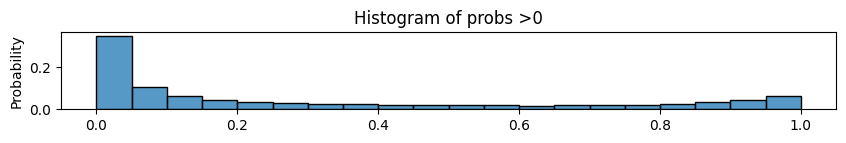

In [3]:
import seaborn as sns
plt.figure(figsize=(10,1))
probs = data.flatten()
sns.histplot(probs[probs > 0], stat='probability', binwidth=0.05)
plt.title("Histogram of probs >0")

In [4]:
df = pd.read_excel('2025.10.09 GPS points CIV GHA.xlsx')
lat_columns = ["T1 Lat", "T2 Lat", "T3 Lat", "T4 Lat", "T5 Lat"]
lon_columns = ["T1 Long", "T2 Long", "T3 Long3", "T4 Long", "T5 Long"]
df = df[["Site", "Longitude", "Latitude", *(lon_columns+lat_columns)]]
df = df.dropna(subset=lat_columns+lon_columns)
df.head(1)

,Site,Longitude,Latitude,T1 Long,T2 Long,T3 Long3,T4 Long,T5 Long,T1 Lat,T2 Lat,T3 Lat,T4 Lat,T5 Lat
0,AB16,NaN,NaN,-3.341247,-3.341366,-3.341791,-3.341375,-3.341386,5.406682,5.406926,5.406391,5.406715,5.406691


In [5]:
print(lat_columns)
print(lon_columns)

polygons = []
for _, row in df.iterrows():
    nodes = []
    for lat_col, lon_col in zip(lat_columns, lon_columns):
        lat, lon = str(row[lat_col]), str(row[lon_col])

        # clean up 
        lat = lat.replace('_', '').replace('|', '').replace(" ", "")
        lon = lon.replace('_', '').replace('|', '').replace(" ", "")

        if lat[-1] == '.':
            lat = lat[:-1]
        if lon[-1] == '.':
            lon = lon[:-1]
        
        nodes.append((float(lon), float(lat)))

    nodes.append(nodes[0])

    polygons.append(Polygon(nodes)) # NOTE: Longitude is X, Latitude is Y

['T1 Lat', 'T2 Lat', 'T3 Lat', 'T4 Lat', 'T5 Lat']
['T1 Long', 'T2 Long', 'T3 Long3', 'T4 Long', 'T5 Long']


In [6]:
polygons = [e for e in polygons if -20 < min(e.bounds) <= max(e.bounds) < 20]
len(polygons)

157

In [7]:
# Convert to convex hull
polygons = [e.convex_hull for e in polygons]

In [17]:
# Create a GeoDataFrame
# We assume the input lat/lon is WGS84 (EPSG:4326)
gdf = gpd.GeoDataFrame(index=range(len(polygons)), crs=src.crs, geometry=polygons)
gdf.head(1)

,geometry
0,"POLYGON ((-3.34179 5.40639, -3.34137 5.40693, ..."


In [9]:
print("Boundaries of polygons")
print("Lon:", gdf.bounds.minx.min(), "-->", gdf.bounds.maxx.max())
print("Lat:", gdf.bounds.miny.min(), "-->", gdf.bounds.maxy.max())

Boundaries of polygons
Lon: -7.935547 --> -3.110957
Lat: 4.758712 --> 7.28489


In [10]:
print("Boundaries of the map")
src.bounds
print("Lon:", src.bounds.left, "-->", src.bounds.right)
print("Lat:", src.bounds.bottom, "-->", src.bounds.top)

Boundaries of the map
Lon: -8.59923 --> 1.1916899999999995
Lat: 4.36182 --> 11.17328


In [11]:
# Build scaled transform, since we're downsampling
scaled_transform = src.transform * src.transform.scale(
    (src.width / data.shape[1]),
    (src.height / data.shape[0])
)

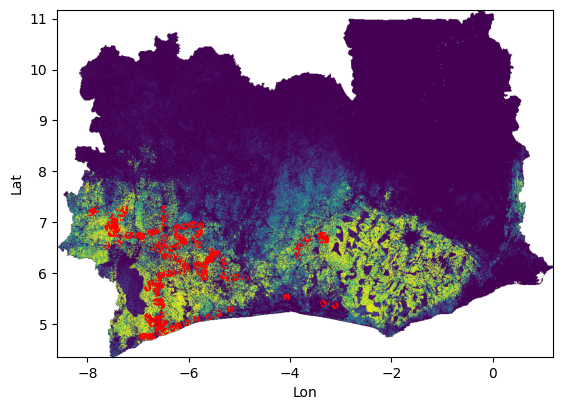

In [12]:
f = plt.figure()
plot.show(data, transform=scaled_transform, ax=plt.gca(), cmap='viridis')
gdf.plot(ax=plt.gca(), edgecolor='red', facecolor='none', linewidth=5)
plt.xlabel('Lon')
plt.ylabel('Lat')
plt.show()

In [26]:
# Extract, for each shape, their contained probabilities
from rasterio import mask
from rasterio.windows import from_bounds

In [27]:
geom_to_masked_proba = {}
with rasterio.open(file_path) as src:
    for geom in gdf.geometry:
        geom = geom.buffer(0.0001) # NOTE: reconsider

        # Figure out window
        minx, miny, maxx, maxy = geom.bounds
        window = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
        
        data = src.read(1, window=window, boundless=True)

        # Build mask
        mask = rasterio.features.rasterize(
            [(geom, 1)],
            out_shape=data.shape,
            transform=src.window_transform(window),
            fill=0,            # Pixels outside the shape
            all_touched=True   # If True, any pixel touched by the line is included
        )
        
        geom_to_masked_proba[geom] = data[mask == 1]

(-3.3418909927832736, 5.406291000482536, -3.3411470322882857, 5.407025937834727)
File CRS: EPSG:4326
Nodata Value: -3.4028234663852886e+38
Data Min/Max: 0.0, 0.017857134342193604
Window size: 8.436771086519002x8.337097456707852 pixels


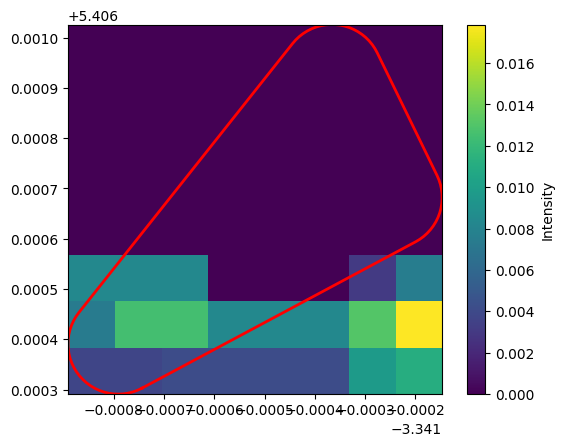

In [40]:
from rasterio.windows import from_bounds

file_path = 'cocoa_map.tif'

geom = list(geom_to_masked_proba)[0]

dilated_geom = geom

minx, miny, maxx, maxy = dilated_geom.bounds
with rasterio.open(file_path) as src:
    print(dilated_geom.bounds)
    print(f"File CRS: {src.crs}")
    print(f"Nodata Value: {src.nodata}")
    print(f"Data Min/Max: {data.min()}, {data.max()}")
    print(f"Window size: {window.width}x{window.height} pixels")
    window = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
    
    data = src.read(1, window=window, boundless=True)

    # Figure out mask
    mask = rasterio.features.rasterize(
        [(geom, 1)],
        out_shape=data.shape,
        transform=src.window_transform(window),
        fill=0,            # Pixels outside the shape
        all_touched=True   # If True, any pixel touched by the line is included
    )
    data[mask == 1]
    
win_bounds = src.window_bounds(window)
extent = [win_bounds[0], win_bounds[2], win_bounds[1], win_bounds[3]]

plt.imshow(data, cmap='viridis', extent=extent)
plt.colorbar(label='Intensity')

# plot geom
x, y = geom.exterior.xy
plt.gca().plot(x, y, color='red', linestyle='-', linewidth=2, label='Geometry Boundary')
    
plt.show()

# NOTE: Some data INSIDE THE LAND are missing --> why ?

array([0.95414144, 0.9354209 , 0.9325253 , 0.94222224, 0.92868686,
       0.91818184, 0.92919195, 0.9011448 , 0.8981145 ], dtype=float32)

In [37]:
for i, (geom, masked_proba) in enumerate(geom_to_masked_proba.items()):
    print(len(masked_proba))

45
9
9
24
19
23
18
12
11
15
3220
12
9
15
9
12
12
12
9
440
15
12
15
9
9
12
9
15
9
9
12
9
12
12
15
20
15
12
11
24
12
16
24
12
15
21
12
23
9
12
9
22
22
4389
9
15
15
35
12
18
19
21
12
16
9
9
22
16
12
12
9
15
9
8
9
17
12
9
6
9
15
12
12
9
9
18
12
16
9
12
15
9
18
9
12
12
15
8
18
11
28
18
15
9
9
15
9
273
12
12
15
18
25
12
21
15
12
15
9
12
17
15
20
9
12
12
37
12
15
11
12
15
46
9
15
40
12
9
15
18
12
16
15
18
15
12
15
22
9
9
16
12
35
19
19
27
9


In [120]:
df = pd.DataFrame({
    'geom': geom_to_masked_proba.keys(),
    'probas': geom_to_masked_proba.values(),
})

df['max_proba'] = df.probas.apply(lambda x: x.max())
df.head(1)

,geom,probas,max_proba
0,POLYGON ((-3.3417438318440147 5.40630282310358...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0125


In [134]:
thresh = 0.65

precision_score(df.max_proba > thresh, [1.0] * len(df))
recall_score(df.max_proba > thresh, [1.0] * len(df))

1.0

In [ ]:
# Issues 

2019 - 2021 -> update 
how to test recall

train model to predict these outputs 